In [2]:
# Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    roc_auc_score,
)

In [3]:
# Load the cleaned dataset
df = pd.read_csv("heart-cleaned.csv")
print(f"Dataset shape: {df.shape}")
print(f"\nFirst few rows:")
df.head()

Dataset shape: (746, 12)

First few rows:


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [4]:
# Separate features and target
X = df.drop(columns=["HeartDisease"])
y = df["HeartDisease"]

# Identify numerical and categorical columns
numerical_cols = ["Age", "RestingBP", "Cholesterol", "FastingBS", "MaxHR", "Oldpeak"]
categorical_cols = ["Sex", "ChestPainType", "RestingECG", "ExerciseAngina", "ST_Slope"]

print(f"Numerical columns: {numerical_cols}")
print(f"Categorical columns: {categorical_cols}")
print(f"\nTarget distribution:")
print(y.value_counts())

Numerical columns: ['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak']
Categorical columns: ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']

Target distribution:
HeartDisease
0    390
1    356
Name: count, dtype: int64


In [5]:
# One-hot encode categorical variables
X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True)
print(f"Shape after encoding: {X_encoded.shape}")
print(f"\nFeature names:")
print(X_encoded.columns.tolist())

Shape after encoding: (746, 15)

Feature names:
['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak', 'Sex_M', 'ChestPainType_ATA', 'ChestPainType_NAP', 'ChestPainType_TA', 'RestingECG_Normal', 'RestingECG_ST', 'ExerciseAngina_Y', 'ST_Slope_Flat', 'ST_Slope_Up']


In [6]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")
print(f"\nTraining target distribution:")
print(y_train.value_counts())
print(f"\nTest target distribution:")
print(y_test.value_counts())

Training set size: 596
Test set size: 150

Training target distribution:
HeartDisease
0    312
1    284
Name: count, dtype: int64

Test target distribution:
HeartDisease
0    78
1    72
Name: count, dtype: int64


In [7]:
# Define function for hyperparameter tuning
def tune_clf_hyperparameters(
    pipeline, param_grid, X_train, y_train, cv=5, scoring="accuracy"
):
    grid_search = GridSearchCV(
        pipeline, param_grid, cv=cv, scoring=scoring, n_jobs=-1, verbose=1
    )
    grid_search.fit(X_train, y_train)

    print(f"\nBest cross-validation score: {grid_search.best_score_:.4f}")
    print(f"Best parameters: {grid_search.best_params_}\n")

    return grid_search.best_estimator_, grid_search.best_params_

In [8]:
# Create SVM pipeline with standardization
svm_pipeline = Pipeline([("scaler", StandardScaler()), ("svm", SVC(random_state=42))])

# Configure hyperparameter grid
param_grid_svm = {
    "svm__C": [0.001, 0.005, 0.01, 0.05, 0.1, 1, 10, 20],
    "svm__kernel": ["linear", "rbf", "poly"],
    "svm__gamma": ["scale", "auto", 0.1, 0.5, 1, 5],
    "svm__degree": [2, 3, 4],
}

# Call the function for hyperparameter tuning
best_svm, best_svm_hyperparams = tune_clf_hyperparameters(
    svm_pipeline, param_grid_svm, X_train, y_train
)

print("SVM Optimal Hyperparameters:")
print("=" * 70)
for param, value in best_svm_hyperparams.items():
    print(f"  {param}: {value}")
print("=" * 70)

Fitting 5 folds for each of 432 candidates, totalling 2160 fits

Best cross-validation score: 0.8674
Best parameters: {'svm__C': 0.05, 'svm__degree': 2, 'svm__gamma': 'scale', 'svm__kernel': 'rbf'}

SVM Optimal Hyperparameters:
  svm__C: 0.05
  svm__degree: 2
  svm__gamma: scale
  svm__kernel: rbf


In [9]:
# Use the best model from hyperparameter tuning
svm_model = best_svm

print("Best SVM model (from hyperparameter tuning) is ready!")
print(
    f"Number of support vectors: {len(svm_model.named_steps['svm'].support_vectors_)}"
)
print(f"Support vectors per class: {svm_model.named_steps['svm'].n_support_}")

Best SVM model (from hyperparameter tuning) is ready!
Number of support vectors: 437
Support vectors per class: [221 216]


In [10]:
# Make predictions using the pipeline (it will handle standardization automatically)
y_train_pred = svm_model.predict(X_train)
y_test_pred = svm_model.predict(X_test)

# Calculate accuracies
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

print("=" * 50)
print("SVM MODEL PERFORMANCE")
print("=" * 50)
print(f"\nTrain Accuracy: {train_accuracy:.4f} ({train_accuracy*100:.2f}%)")
print(f"Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print("\n" + "=" * 50)
print("\nConfusion Matrix (Test Set):")
print(confusion_matrix(y_test, y_test_pred))
print("\nClassification Report (Test Set):")
print(
    classification_report(
        y_test, y_test_pred, target_names=["0: No Heart Disease", "1: Heart Disease"]
    )
)

SVM MODEL PERFORMANCE

Train Accuracy: 0.8758 (87.58%)
Test Accuracy: 0.8533 (85.33%)


Confusion Matrix (Test Set):
[[67 11]
 [11 61]]

Classification Report (Test Set):
                     precision    recall  f1-score   support

0: No Heart Disease       0.86      0.86      0.86        78
   1: Heart Disease       0.85      0.85      0.85        72

           accuracy                           0.85       150
          macro avg       0.85      0.85      0.85       150
       weighted avg       0.85      0.85      0.85       150



ROC CURVE ANALYSIS


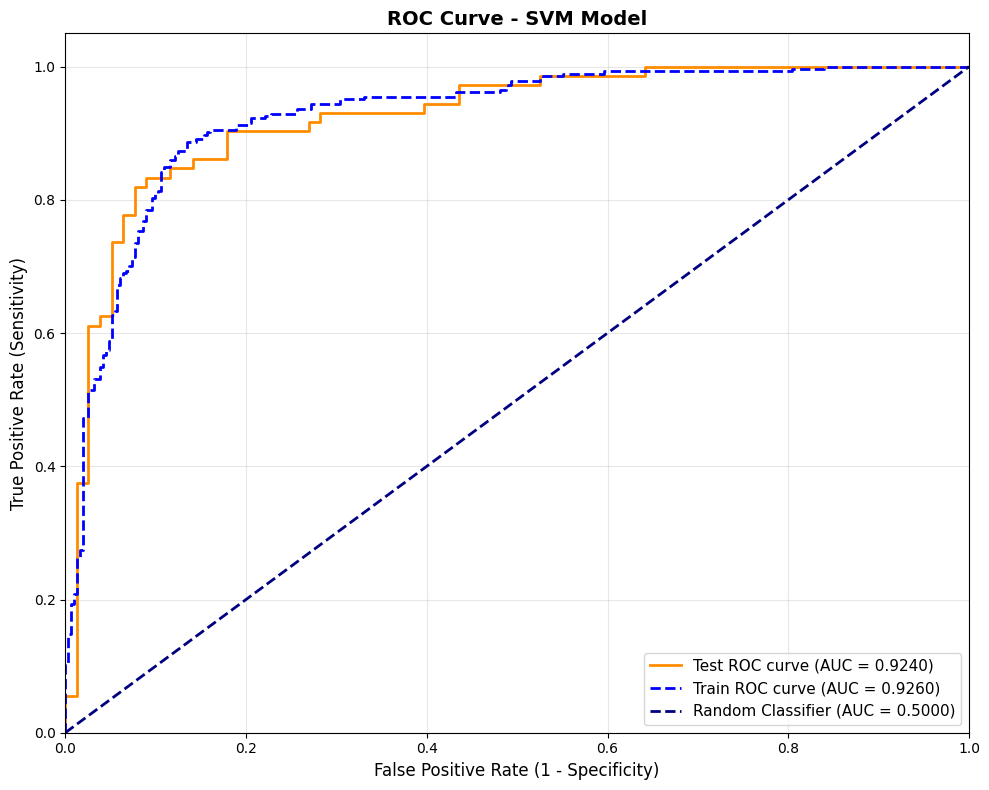


ROC-AUC Score (Test Set): 0.9240
ROC-AUC Score (Train Set): 0.9260

Interpretation:
  - AUC = 0.5: Random classifier (no discriminative ability)
  - AUC = 1.0: Perfect classifier
  - AUC > 0.8: Good classifier
  - AUC > 0.9: Excellent classifier

Our model has an AUC of 0.9240, which indicates excellent performance.


In [11]:
# Plot ROC Curve
print("=" * 70)
print("ROC CURVE ANALYSIS")
print("=" * 70)

# Get decision function scores (SVM doesn't output probabilities by default)
# We need to use decision_function() to get scores for ROC curve
y_train_scores = svm_model.decision_function(X_train)
y_test_scores = svm_model.decision_function(X_test)

# Calculate ROC curve for test set
fpr, tpr, thresholds = roc_curve(y_test, y_test_scores)
roc_auc = roc_auc_score(y_test, y_test_scores)

# Also calculate for training set for comparison
fpr_train, tpr_train, thresholds_train = roc_curve(y_train, y_train_scores)
roc_auc_train = roc_auc_score(y_train, y_train_scores)

# Plot ROC curves
plt.figure(figsize=(10, 8))
plt.plot(fpr, tpr, color='darkorange', lw=2, 
         label=f'Test ROC curve (AUC = {roc_auc:.4f})')
plt.plot(fpr_train, tpr_train, color='blue', lw=2, linestyle='--',
         label=f'Train ROC curve (AUC = {roc_auc_train:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', 
         label='Random Classifier (AUC = 0.5000)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
plt.ylabel('True Positive Rate (Sensitivity)', fontsize=12)
plt.title('ROC Curve - SVM Model', fontsize=14, fontweight='bold')
plt.legend(loc="lower right", fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nROC-AUC Score (Test Set): {roc_auc:.4f}")
print(f"ROC-AUC Score (Train Set): {roc_auc_train:.4f}")
print(f"\nInterpretation:")
print(f"  - AUC = 0.5: Random classifier (no discriminative ability)")
print(f"  - AUC = 1.0: Perfect classifier")
print(f"  - AUC > 0.8: Good classifier")
print(f"  - AUC > 0.9: Excellent classifier")
print(f"\nOur model has an AUC of {roc_auc:.4f}, which indicates {'excellent' if roc_auc > 0.9 else 'good' if roc_auc > 0.8 else 'moderate'} performance.")
print("=" * 70)


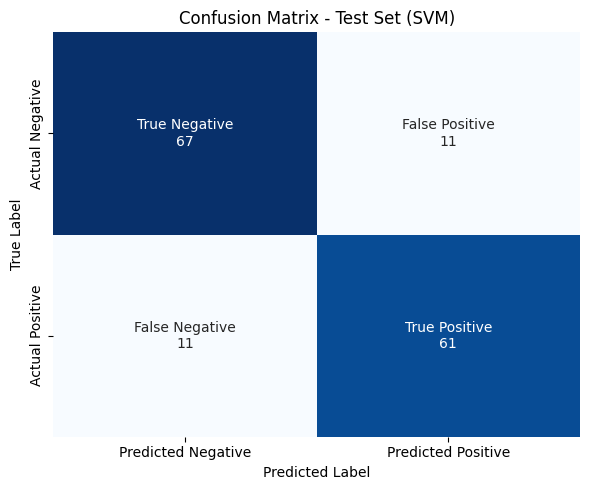

In [12]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Assuming you already have y_test and y_test_pred
# y_test = ...
# y_test_pred = ...

cm = confusion_matrix(y_test, y_test_pred)

# 1. Create the text labels
group_names = ['True Negative', 'False Positive', 'False Negative', 'True Positive']
group_counts = ["{0:0.0f}".format(value) for value in cm.flatten()]

# Combine the text and the number with a newline character
labels = [f"{v1}\n{v2}" for v1, v2 in zip(group_names, group_counts)]
labels = np.asarray(labels).reshape(2,2)

# 2. Create the DataFrame (Standard structure)
cm_df = pd.DataFrame(
    cm, 
    index=["Actual Negative", "Actual Positive"], 
    columns=["Predicted Negative", "Predicted Positive"]
)

# 3. Plot
plt.figure(figsize=(6, 5))
sns.heatmap(cm_df, annot=labels, fmt='', cmap="Blues", cbar=False)

plt.title("Confusion Matrix - Test Set (SVM)")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.show()

In [13]:
# Summary of results
print("=" * 70)
print("FINAL SUMMARY")
print("=" * 70)
print(f"\nDataset Information:")
print(f"  - Total samples: {len(df)}")
print(f"  - Training samples: {len(X_train)}")
print(f"  - Test samples: {len(X_test)}")
print(f"  - Number of features (after encoding): {X_encoded.shape[1]}")
print(f"\nSVM Model Configuration (Optimized):")
print(f"  - Kernel: {best_svm_hyperparams['svm__kernel']}")
print(f"  - C parameter: {best_svm_hyperparams['svm__C']}")
print(f"  - Gamma: {best_svm_hyperparams['svm__gamma']}")
if 'svm__degree' in best_svm_hyperparams:
    print(f"  - Degree: {best_svm_hyperparams['svm__degree']}")
print(f"  - Number of support vectors: {len(svm_model.named_steps['svm'].support_vectors_)}")
print(f"  - Support vectors per class: {svm_model.named_steps['svm'].n_support_}")

# Calculate detailed metrics for both classes
precision = precision_score(y_test, y_test_pred, average=None)
recall = recall_score(y_test, y_test_pred, average=None)
f1 = f1_score(y_test, y_test_pred, average=None)

print(f"\nModel Performance (Test Set):")
print(f"  Precision (No Heart Disease): {precision[0]:.2f}")
print(f"  Recall (No Heart Disease): {recall[0]:.2f}")
print(f"  F1-Score (No Heart Disease): {f1[0]:.2f}")
print(f"  Precision (Heart Disease): {precision[1]:.2f}")
print(f"  Recall (Heart Disease): {recall[1]:.2f}")
print(f"  F1-Score (Heart Disease): {f1[1]:.2f}")
print(f"  Overall Accuracy: {test_accuracy*100:.2f}%")
print("=" * 70)

FINAL SUMMARY

Dataset Information:
  - Total samples: 746
  - Training samples: 596
  - Test samples: 150
  - Number of features (after encoding): 15

SVM Model Configuration (Optimized):
  - Kernel: rbf
  - C parameter: 0.05
  - Gamma: scale
  - Degree: 2
  - Number of support vectors: 437
  - Support vectors per class: [221 216]

Model Performance (Test Set):
  Precision (No Heart Disease): 0.86
  Recall (No Heart Disease): 0.86
  F1-Score (No Heart Disease): 0.86
  Precision (Heart Disease): 0.85
  Recall (Heart Disease): 0.85
  F1-Score (Heart Disease): 0.85
  Overall Accuracy: 85.33%
